In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("(Upto_Data_Preprocessing)HR_HIRING_ANALYTICS.csv")

data = pd.DataFrame(df)

data

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,...,Age,LOB_Id,Domicile_Id,Status,Date_of_Interview,LOB,Domicile_Name,Location_Name,Region_Id,Region_Name
0,1,2110407,Yes,14,30,E2,-20.79,13.16,33.95,No,...,34.0,1,D6,Joined,2013-01-08,ERS,Goa,Noida,R1,North
1,2,2112635,No,18,30,E2,50.00,320.00,270.00,No,...,34.0,2,D9,Joined,2013-01-12,INFRA,Himachal Pradesh,Chennai,R2,South
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,...,27.0,2,D10,Joined,2013-01-25,INFRA,Jharkhand,Noida,R1,North
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,...,34.0,2,D3,Joined,2013-01-27,INFRA,Chandigarh,Noida,R1,North
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,...,34.0,2,D21,Joined,2013-01-28,INFRA,Tripura,Noida,R1,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,8991,3822427,No,4,0,E1,191.67,191.67,0.00,No,...,34.0,1,D21,Joined,2013-08-19,ERS,Tripura,Chennai,R2,South
8991,8992,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,...,34.0,4,D9,Joined,2013-08-20,BFSI,Himachal Pradesh,Chennai,R2,South
8992,8993,3834159,No,0,0,E2,35.42,35.42,0.00,No,...,34.0,2,D18,Joined,2013-08-20,INFRA,Rajasthan,Noida,R1,North
8993,8994,3835433,No,0,30,E1,76.92,53.85,-23.07,No,...,34.0,2,D2,Joined,2013-08-20,INFRA,Bihar,Noida,R1,North


# Q1. Analysis of percentage joined of offer released.

In [114]:
Joined = list(data['Status'].value_counts())[0]
Not_Joined = list(data['Status'].value_counts())[1]

print(f"No of candidates joined of offer released = {Joined}")
print(f"No of candidates not joined of offer released = {Not_Joined}")

# ---------------------------------------------------------------------------------

Total_candidates = data.shape[0]

print(f"Total No of Candidiates = {Total_candidates}")

# ---------------------------------------------------------------------------------

joined_pct = (Joined / Total_candidates) * 100
not_joined_pct = (Not_Joined / Total_candidates) * 100

print(f"Percentage joined of offer release = {joined_pct : .2f} %")

No of candidates joined of offer released = 7313
No of candidates not joined of offer released = 1682
Total No of Candidiates = 8995
Percentage joined of offer release =  81.30 %


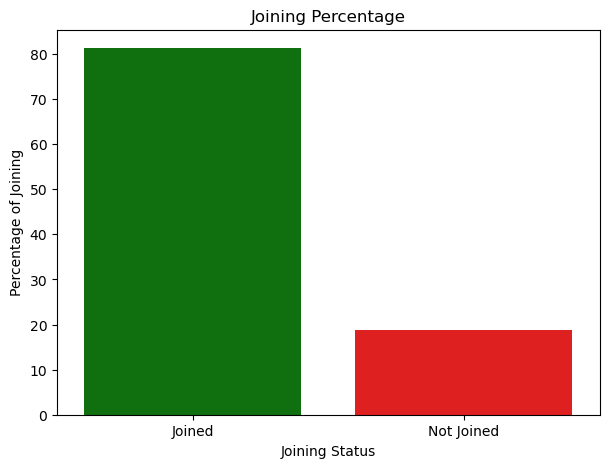

In [31]:
plt.figure(figsize = (7,5))

x = ['Joined', 'Not Joined']
y = [joined_pct, not_joined_pct]
colors = ['green', 'red']

sns.barplot(x=x, y=y, palette=colors)

plt.title("Joining Percentage")
plt.xlabel("Joining Status")
plt.ylabel("Percentage of Joining")

plt.show()

# Q2. What are the key drivers that influence the candidate joining/not joining a company?

In [127]:
useful_features_numerical = ['Acceptance_days','Notice_Period', 'Offered_CTC_hike_pct', 
            'Expected_CTC_hike_pct', 'CTC_diff_pct']

result = df.groupby('Status')[useful_features_numerical].mean().round(2)
print(result)

            Acceptance_days  Notice_Period  Offered_CTC_hike_pct  \
Status                                                             
Joined                20.62          37.24                 41.13   
Not Joined            24.96          48.19                 38.59   

            Expected_CTC_hike_pct  CTC_diff_pct  
Status                                           
Joined                      43.86         -2.73  
Not Joined                  43.88         -5.29  


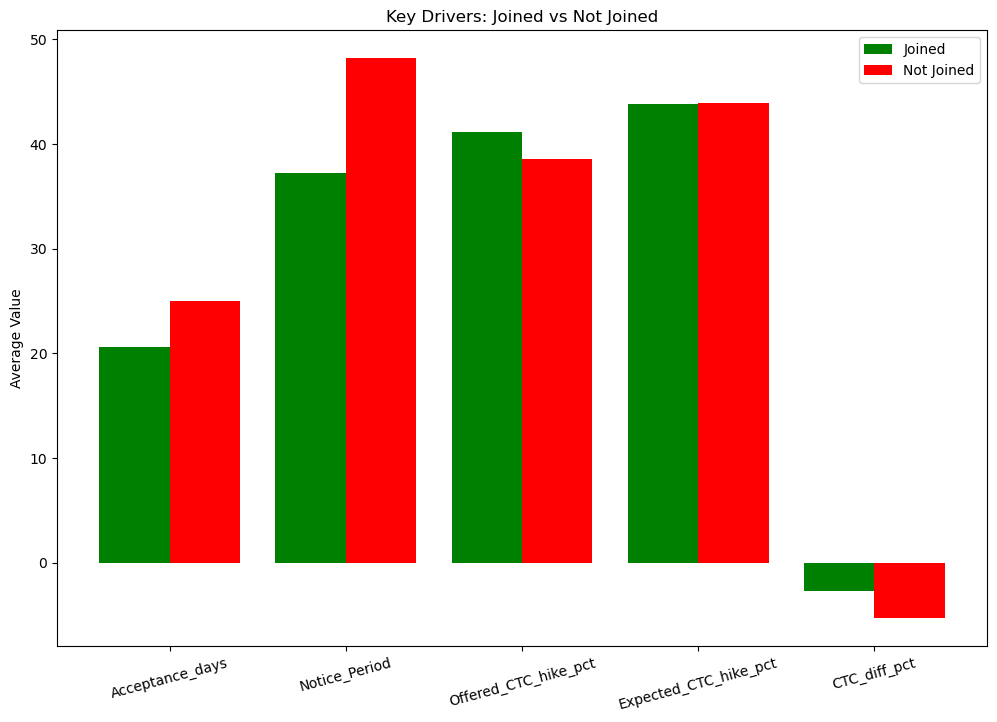

In [129]:
fig, ax = plt.subplots(figsize=(12, 8))   

x = np.arange(len(useful_features_numerical))
width = 0.4

ax.bar(x - width/2, result.loc['Joined'], width, label='Joined', color='green')  
ax.bar(x + width/2, result.loc['Not Joined'], width, label='Not Joined', color='red')   

ax.set_title('Key Drivers: Joined vs Not Joined')  
ax.set_xticks(x)
ax.set_xticklabels(useful_features_numerical, rotation=15)   
ax.set_ylabel('Average Value')
ax.legend()

plt.show()

In [96]:
useful_features_categorical = list(data.select_dtypes(exclude='number').columns)

useful_features_categorical.remove('Date_of_Interview')
useful_features_categorical.remove('Status')

for col in useful_features_categorical:

    result_cat = df.groupby([col, 'Status']).size().unstack()

    print(result_cat)

Status        Joined  Not Joined
DOJ_Extended                    
No              3882         906
Yes             3431         776
Status        Joined  Not Joined
Offered_Band                    
E0               161          50
E1              4536        1042
E2              2188         516
E3               428          74
Status         Joined  Not Joined
Joining_Bonus                    
No               6977        1601
Yes               336          81
Status                     Joined  Not Joined
Candidate_relocate_actual                    
No                         6023.0      1682.0
Yes                        1290.0         NaN
Status  Joined  Not Joined
Gender                    
Female    1278         273
Male      6035        1409
Status             Joined  Not Joined
Candidate_Source                     
Agency               1960         625
Direct               3937         864
Employee Referral    1416         193
Status       Joined  Not Joined
Location_ID         

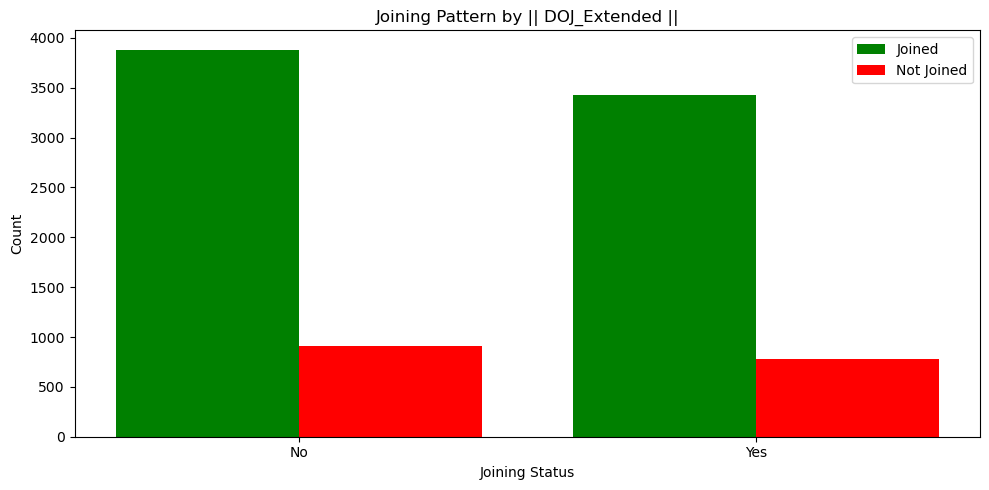

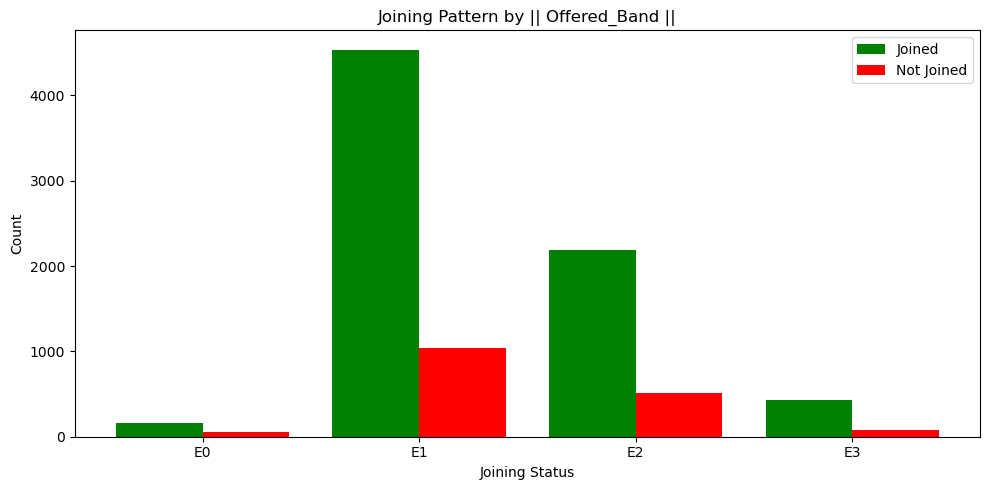

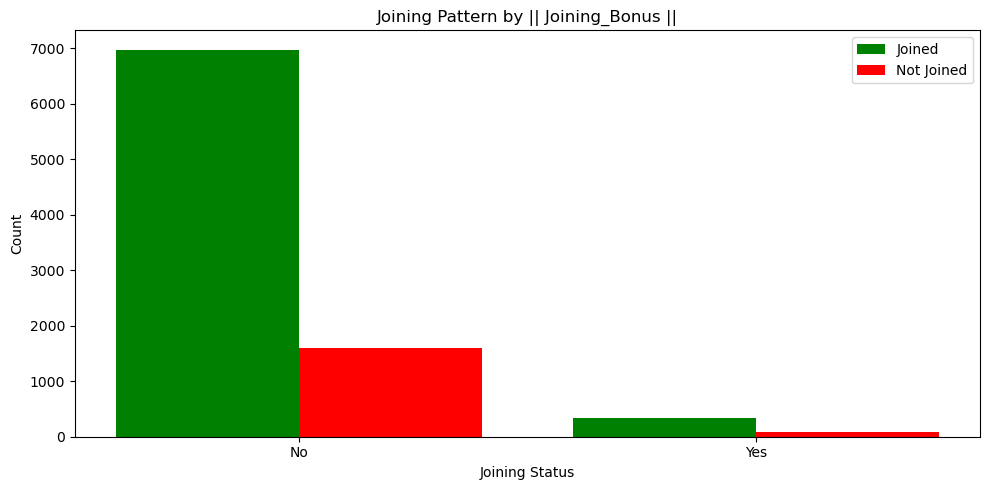

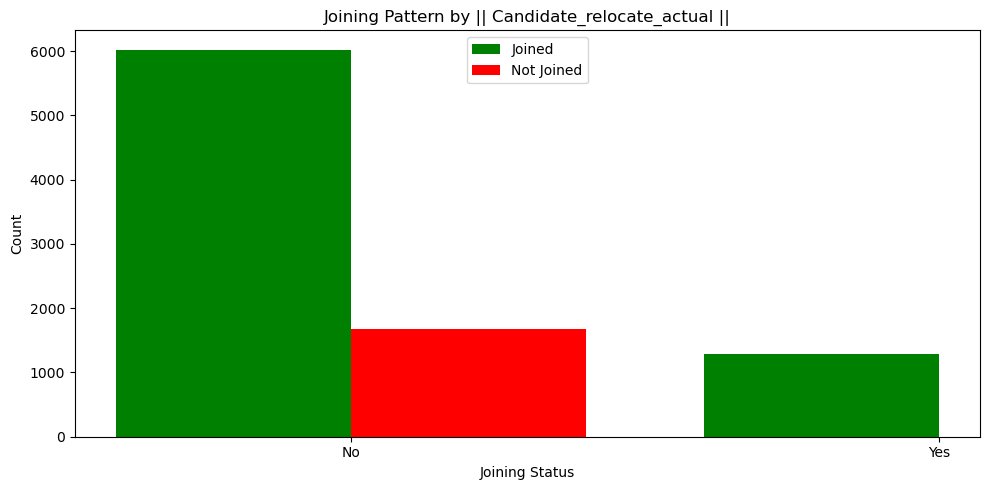

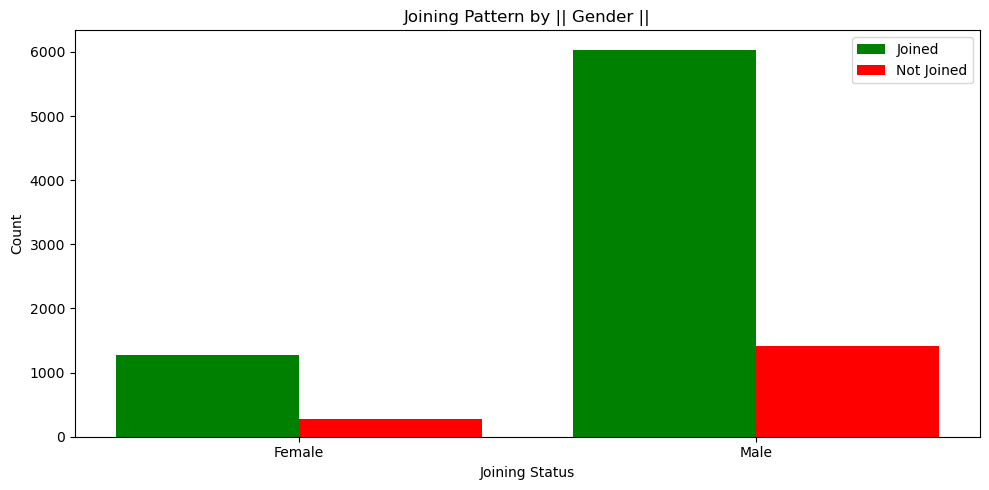

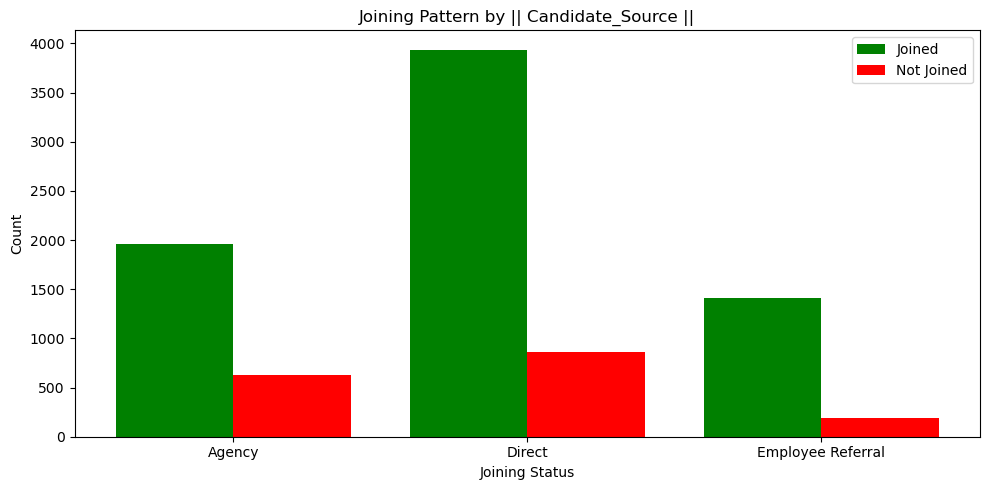

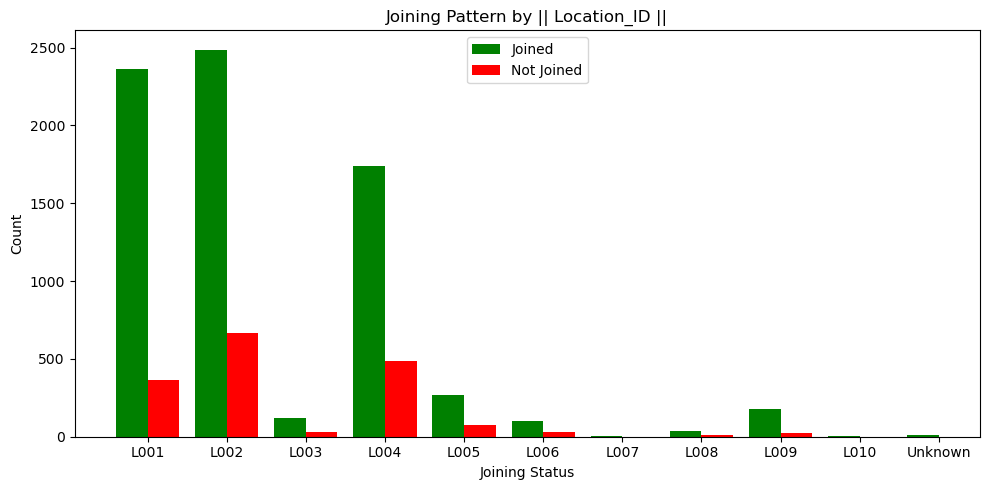

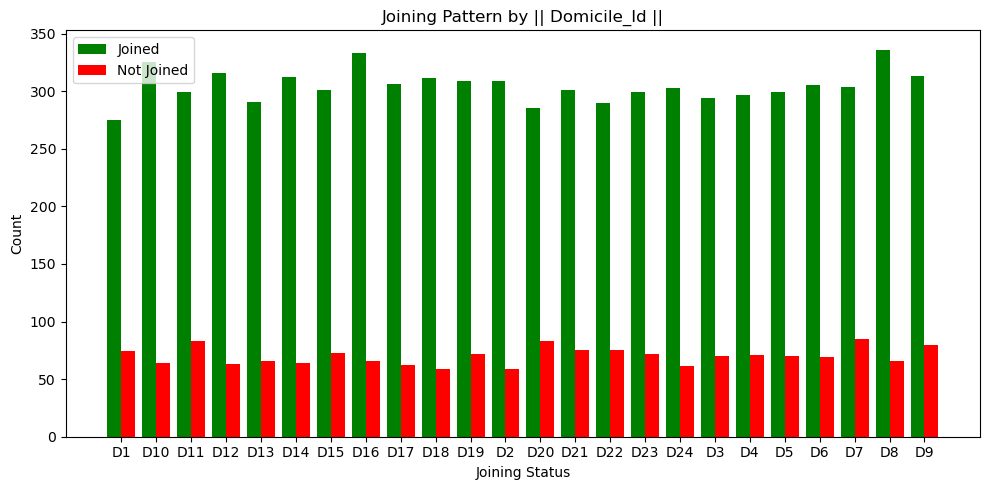

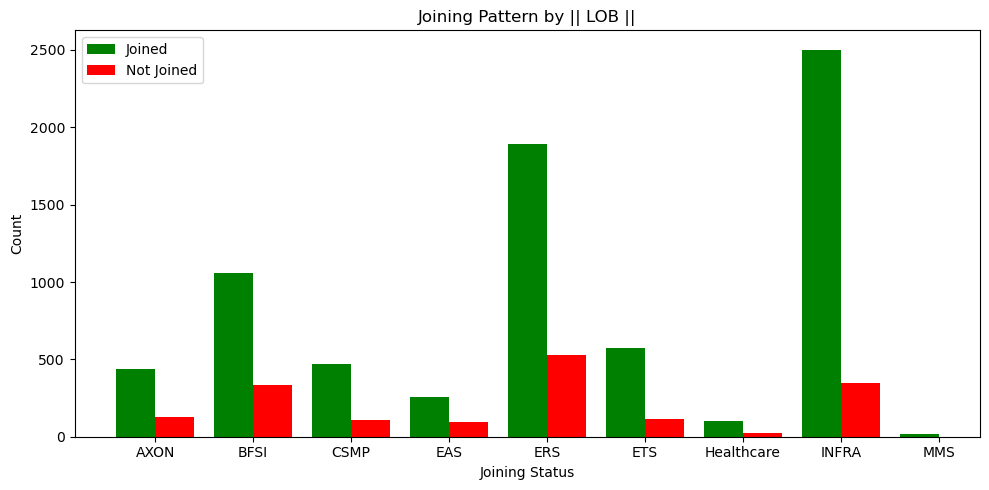

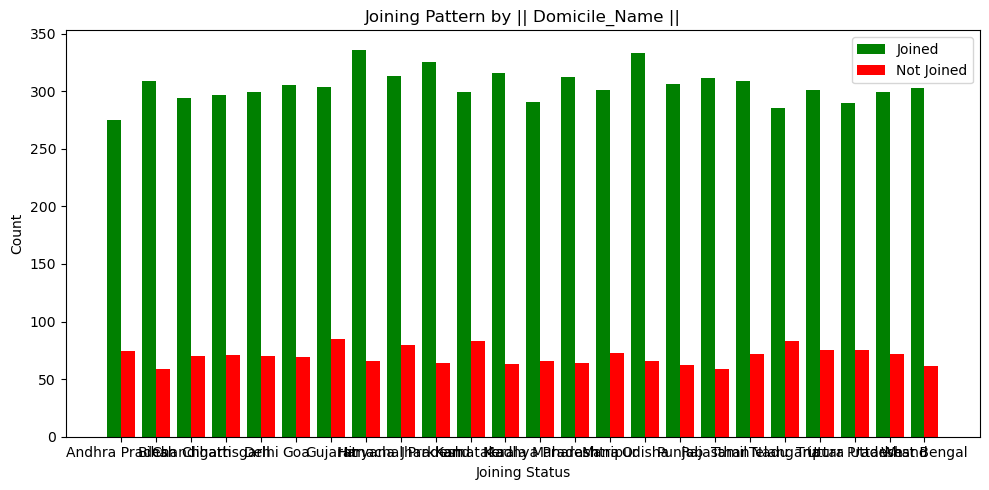

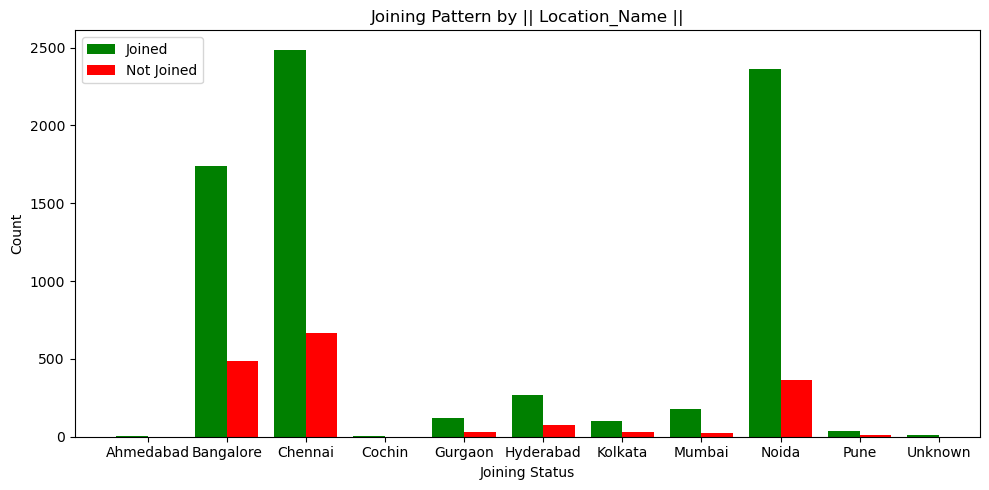

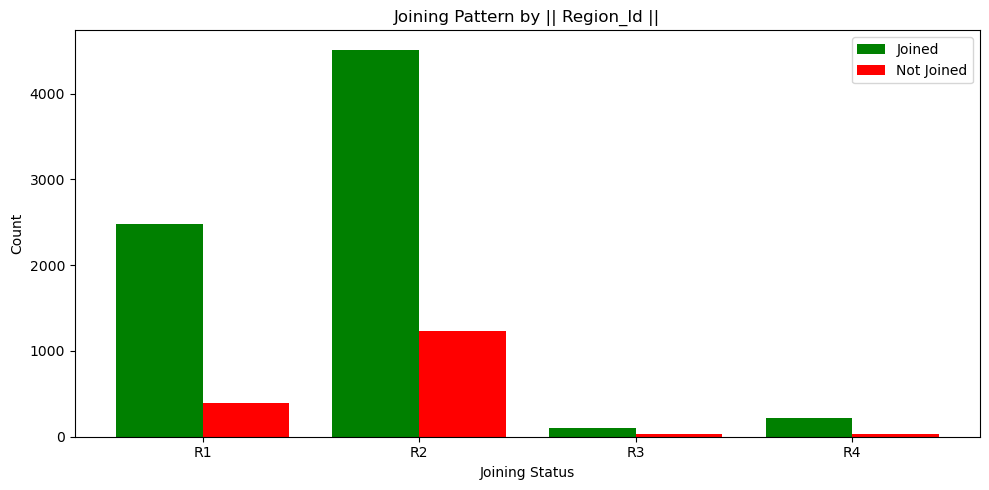

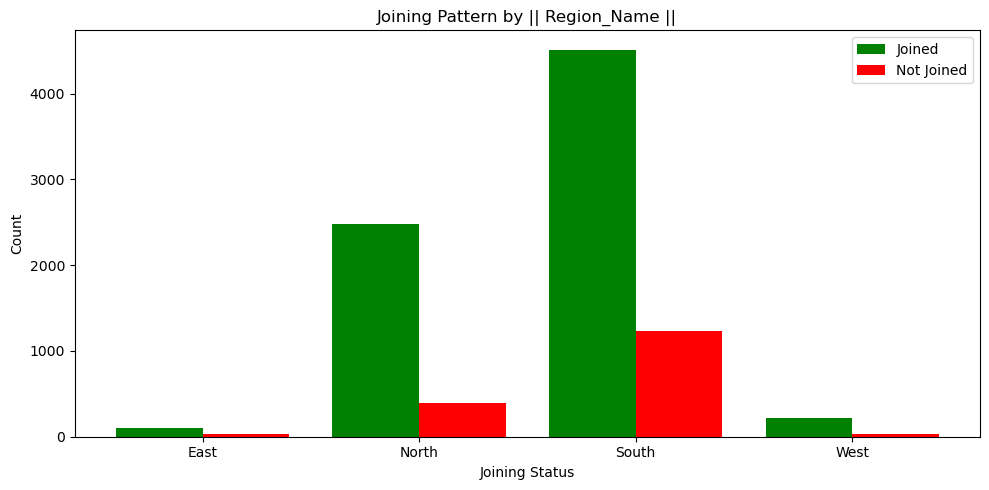

In [97]:
for col in useful_features_categorical:

    result_category = data.groupby([col, 'Status']).size().unstack()

    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(result_category.index))
    width = 0.4

    ax.bar(x - width/2, result_category['Joined'], width, label='Joined', color='green')
    ax.bar(x + width/2, result_category['Not Joined'], width, label='Not Joined', color='red')

    ax.set_title(f'Joining Pattern by || {col} ||')
    ax.set_xticks(x)
    ax.set_xticklabels(result_category.index)
    ax.set_xlabel("Joining Status")
    ax.set_ylabel('Count')
    ax.legend()

    plt.tight_layout()
    plt.show()

# Answer - 

## Impact Drivers


1. Notice_Period — higher the notice period lower the joining chances.

2. CTC_diff_pct — if ctc is offered less chances of dropout for candidate is more

3. Candidate_Source — referrals convert significantly better but direct joining is in highest number of joining 

4. Offered_Band — higher band = higher join rate

5. Candidate_relocate_actual — Very few candidates who are not offered rellocation haven't joined the company.

6. LOB — INFRA has the highest number of joining

7. Region_Name — South has most number of joining candidates

8. DOJ_Extended — slight influence

9. Gender — males joining more than females

10. Joining_Bonus — negligible difference

11. Domicile_Name / Domicile_Id — very uniform across states

12. Location_ID — slight impact

13. Expected_CTC_hike_pct — almost identical in both the cases

# Q3. Are there specific locations where candidates are not joining?

In [98]:
location_stats = data.groupby('Location_Name')['Status'].value_counts().unstack()

location_stats['Total'] = location_stats['Joined'] + location_stats['Not Joined']

location_stats['Drop_Rate'] = (location_stats['Not Joined'] / location_stats['Total'] * 100).round(2)

location_stats = location_stats.sort_values('Drop_Rate', ascending=False)

print("Location-wise Drop Rate:\n")
print(location_stats[['Joined', 'Not Joined', 'Total', 'Drop_Rate']])

Location-wise Drop Rate:

Status         Joined  Not Joined   Total  Drop_Rate
Location_Name                                       
Kolkata         100.0        29.0   129.0      22.48
Hyderabad       266.0        75.0   341.0      21.99
Bangalore      1742.0       488.0  2230.0      21.88
Chennai        2486.0       664.0  3150.0      21.08
Pune             38.0        10.0    48.0      20.83
Gurgaon         118.0        28.0   146.0      19.18
Ahmedabad         5.0         1.0     6.0      16.67
Noida          2362.0       365.0  2727.0      13.38
Cochin            7.0         1.0     8.0      12.50
Mumbai          176.0        21.0   197.0      10.66
Unknown          13.0         NaN     NaN        NaN


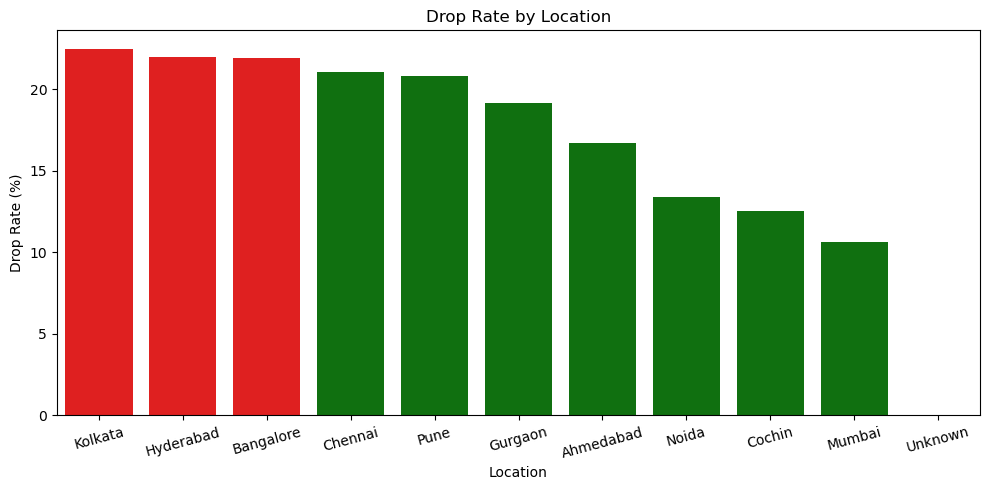

In [99]:
colors = ['red' if value >= 21.5 else 'green' for value in location_stats['Drop_Rate']]

plt.figure(figsize=(10, 5))

sns.barplot(x=location_stats.index, y=location_stats['Drop_Rate'], palette=colors)

plt.xlabel('Location')
plt.ylabel('Drop Rate (%)')
plt.title('Drop Rate by Location')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# Answer - 
- We can see 3 location Kolkata, Hyderabad, Bangalore having highest percentage of drop out rate.
- So, we can say in these location some candidates are not joining. 
- But, we also have to keep in mind that number of toal candidate is more in these locations.

# Q4. Joining status depends on the duration to accept an offer?

In [100]:
print(data.groupby('Status')['Acceptance_days'].describe().round(2))

             count   mean    std  min  25%   50%   75%    max
Status                                                       
Joined      7313.0  20.62  24.44  0.0  2.0  10.0  32.0  143.0
Not Joined  1682.0  24.96  30.86  0.0  4.0  10.0  37.0  224.0


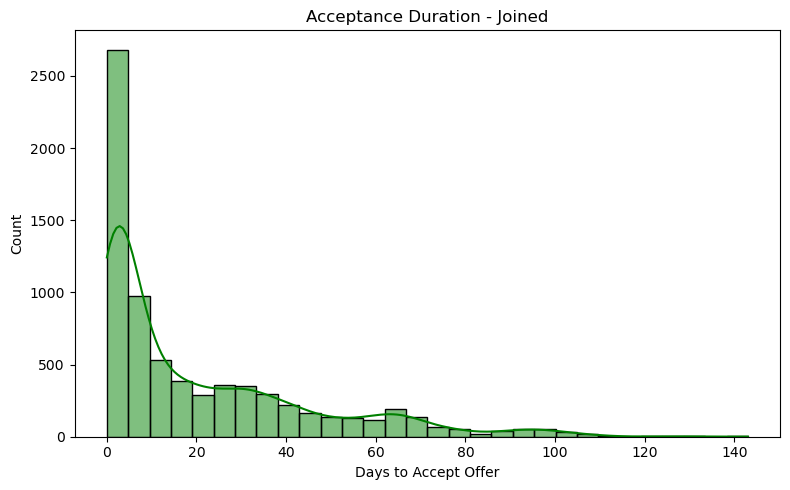

In [101]:
joined = data[data['Status'] == 'Joined']['Acceptance_days']

plt.figure(figsize=(8, 5))
sns.histplot(joined, bins=30, color='green', kde=True)
plt.xlabel('Days to Accept Offer')
plt.ylabel('Count')
plt.title('Acceptance Duration - Joined')

plt.tight_layout()
plt.show()

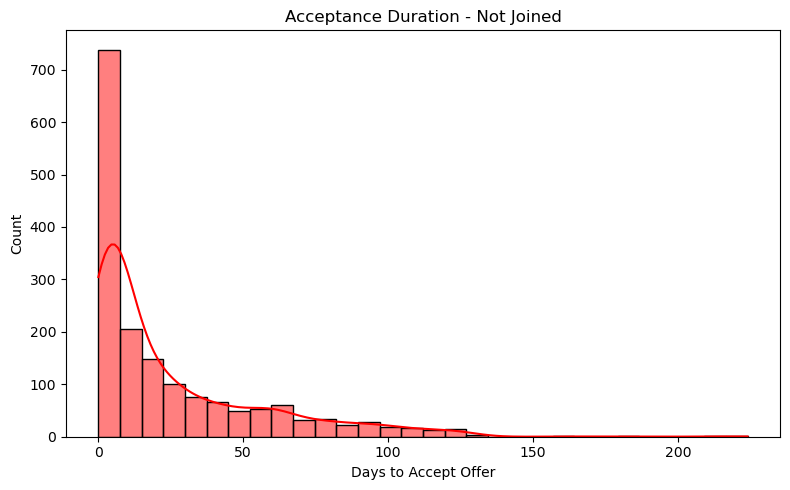

In [103]:
not_joined = data[data['Status'] == 'Not Joined']['Acceptance_days']

plt.figure(figsize=(8, 5))
sns.histplot(not_joined, bins=30, color='red', kde=True)
plt.xlabel('Days to Accept Offer')
plt.ylabel('Count')
plt.title('Acceptance Duration - Not Joined')

plt.tight_layout()
plt.show()

# Answer - 

- Joining status depends upon Duration of Accept an Offer.
- Lower the Acceptance Days higher the chances of joining for a candidate.
- And higher the Acceptance Days lower the chances of joining for a candidate.
- Though exceptions are there, but its a general trend.

In [133]:
corr_value = data['Acceptance_days'].corr(data['Status_Encoded'])
print(f"Correlation between Expected CTC Hike and Joining Status: {corr_value:.4f}")

Correlation between Expected CTC Hike and Joining Status: -0.0654


But the correlation value between Acceptance_days and status is very less

# Q5. Hike offered has an impact on joining status?

In [95]:
useful_features_numerical

['Notice_Period',
 'Offered_CTC_hike_pct',
 'Expected_CTC_hike_pct',
 'CTC_diff_pct']

In [112]:
hike_on_joining = data.groupby('Status')['Expected_CTC_hike_pct'].describe()

hike_on_joining

,count,mean,std,min,25%,50%,75%,max
Status,,,,,,,,
Joined,7313.0,43.860660,30.455099,-62.50,27.03,40.00,53.8500,359.77
Not Joined,1682.0,43.882818,26.708672,-68.83,28.57,41.18,55.5125,294.74


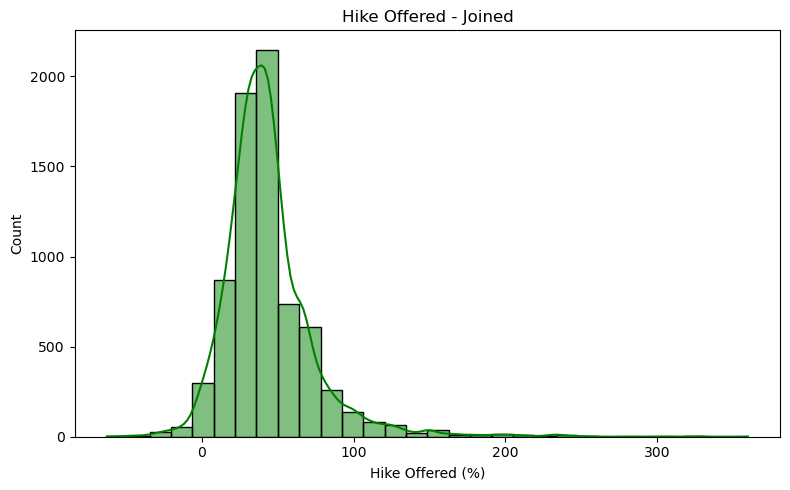

In [109]:
joined = data[data['Status'] == 'Joined']['Expected_CTC_hike_pct']

plt.figure(figsize=(8, 5))
sns.histplot(joined, bins=30, color='green', kde=True)
plt.xlabel('Hike Offered (%)')
plt.ylabel('Count')
plt.title('Hike Offered - Joined')

plt.tight_layout()
plt.show()

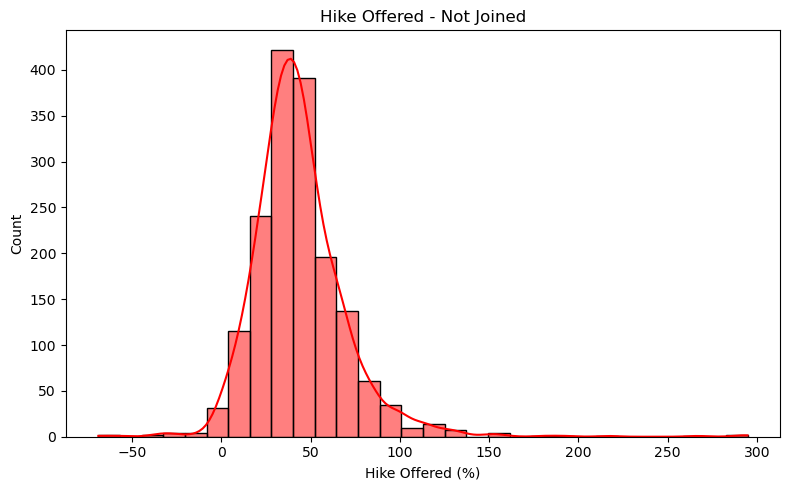

In [113]:
joined = data[data['Status'] == 'Not Joined']['Expected_CTC_hike_pct']

plt.figure(figsize=(8, 5))
sns.histplot(joined, bins=30, color='red', kde=True)
plt.xlabel('Hike Offered (%)')
plt.ylabel('Count')
plt.title('Hike Offered - Not Joined')

plt.tight_layout()
plt.show()

# Answer - 

- Most of the candidates joined have an Expected CTC hike between 30 - 100 %
- If the hike is less than 0 that means negative ctc hike then very few have joined only.

In [117]:
data['Status_Encoded'] = data['Status'].map({'Joined': 1, 'Not Joined': 0})

corr_value = data['Expected_CTC_hike_pct'].corr(data['Status_Encoded'])
print(f"Correlation between Expected CTC Hike and Joining Status: {corr_value:.4f}")

Correlation between Expected CTC Hike and Joining Status: -0.0003


`But the problem is the correlation between Expected_CTC_hike_pct and Status is very low. 
So Expected_CTC_hike_pct can barely do any impact on Status.`

In [132]:
useful_features_numerical

['Acceptance_days',
 'Notice_Period',
 'Offered_CTC_hike_pct',
 'Expected_CTC_hike_pct',
 'CTC_diff_pct']